# 62 - Forward-Backward Speckle-Adaptive UltraTimTrack

Redo of Notebook 59 with forward-backward block-matching error folded into the local confidence value.

This notebook keeps the same Level 1 probabilistic/adaptive-R idea: the fixed-R UltraTimTrack result remains the baseline, local speckle confidence is computed frame-by-frame, and the confidence maps to a bounded Kalman measurement-noise scale. The difference is that a block match must also be self-consistent when matched back from frame `t` to frame `t-1`.

The starting rule-of-thumb values under test are:

- `block_size = 21`
- `stride = 24`
- `search_radius = 8`
- `zncc_low = 0.45`
- `zncc_high = 0.90`
- `confidence_floor = 0.05`
- `r_min_scale = 0.5`
- `r_max_scale = 20.0`
- `r_gamma = 1.5`


## 1. Imports and Project Setup

Repository map used by this notebook:

- Video loading: `ultrasound_tracker.ultratrack_klt.read_gray_frames`, OpenCV `VideoCapture`.
- ROIs: `data/rois/UltraTimTrack_test_rois.json`, `ultrasound_tracker.roi` for interactive ROI provenance.
- Baseline: strict fixed-R UltraTimTrack output from `results/strict_ultratimtrack_runs`.
- Adaptive R: `ultrasound_tracker.ultratimtrack_matlab_2state.run_matlab_2state_kalman` with `measurement_r_scale`.
- Confidence mapping: `ultrasound_tracker.speckle_confidence.SpeckleConfidenceConfig` and `confidence_to_r_scale`.


In [1]:
from __future__ import annotations

import csv
import json
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ultrasound_tracker.speckle_confidence import SpeckleConfidenceConfig, confidence_to_r_scale
from ultrasound_tracker.ultratimtrack_matlab_2state import (
    MatlabTwoStateKalmanConfig,
    run_matlab_2state_kalman,
)
from ultrasound_tracker.ultratrack_klt import read_gray_frames

VIDEO = ROOT / 'data' / 'raw' / 'UltraTimTrack_test.mp4'
ROI_PATH = ROOT / 'data' / 'rois' / 'UltraTimTrack_test_rois.json'
STRICT_BASELINE = ROOT / 'results' / 'strict_ultratimtrack_runs' / 'UltraTimTrack_test' / 'UltraTimTrack_test_strict_results.npz'
UTT_EXPORT = Path('/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat')
OUT = ROOT / 'results' / 'notebook62_forward_backward_speckle_adaptive_R'
OUT.mkdir(parents=True, exist_ok=True)

# Proof-of-concept window. Set to None to compute confidence for the full sequence.
MAX_SECONDS = 30.0
FORCE_RECOMPUTE_CONFIDENCE = False

CONFIG = SpeckleConfidenceConfig(
    block_size=21,
    stride=24,
    search_radius=8,
    zncc_low=0.45,
    zncc_high=0.90,
    confidence_floor=0.05,
    r_min_scale=0.5,
    r_max_scale=20.0,
    r_gamma=1.5,
)
PATCH_RADIUS = CONFIG.block_size // 2
GRID_BORDER = PATCH_RADIUS + CONFIG.search_radius + 4
VALID_FRACTION_FLOOR = 0.25
CONFIG_SUMMARY = {
    'block_size': CONFIG.block_size,
    'stride': CONFIG.stride,
    'search_radius': CONFIG.search_radius,
    'zncc_low': CONFIG.zncc_low,
    'zncc_high': CONFIG.zncc_high,
    'confidence_floor': CONFIG.confidence_floor,
    'r_min_scale': CONFIG.r_min_scale,
    'r_max_scale': CONFIG.r_max_scale,
    'r_gamma': CONFIG.r_gamma,
    'forward_backward_scale_px': CONFIG.forward_backward_scale_px,
    'motion_spread_scale_px': CONFIG.motion_spread_scale_px,
}

for path in [VIDEO, ROI_PATH, STRICT_BASELINE, UTT_EXPORT]:
    print(path, 'OK' if path.exists() else 'MISSING')
print('confidence config:', CONFIG_SUMMARY)


Matplotlib is building the font cache; this may take a moment.


/Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4 OK
/Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json OK
/Users/grosbedou/PycharmProjects/NDORMS/results/strict_ultratimtrack_runs/UltraTimTrack_test/UltraTimTrack_test_strict_results.npz OK
/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat OK
confidence config: {'block_size': 21, 'stride': 24, 'search_radius': 8, 'zncc_low': 0.45, 'zncc_high': 0.9, 'confidence_floor': 0.05, 'r_min_scale': 0.5, 'r_max_scale': 20.0, 'r_gamma': 1.5, 'forward_backward_scale_px': 2.0, 'motion_spread_scale_px': 3.0}


## 2-4. Load Video, ROIs, and Fixed-R UltraTimTrack Baseline

The fixed-R result is loaded from the current working strict runner output. This preserves the current UltraTimTrack behavior and avoids recomputing TimTrack/Hough/KLT in this exploratory notebook.

In [2]:
def video_info(path: Path) -> tuple[float, int, int, int]:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise FileNotFoundError(path)
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    ok, frame0 = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f'Could not read first frame from {path}')
    return fps, n_frames, int(frame0.shape[0]), int(frame0.shape[1])


with ROI_PATH.open('r', encoding='utf-8') as f:
    rois = json.load(f)
fascicle_roi = tuple(int(v) for v in rois['fascicle'])

fps, video_n_frames, image_h, image_w = video_info(VIDEO)
baseline = np.load(STRICT_BASELINE, allow_pickle=True)
n_all = min(len(baseline['frame']), video_n_frames)
if MAX_SECONDS is None:
    n_conf = n_all
else:
    n_conf = min(n_all, int(round(float(MAX_SECONDS) * fps)))

time_all = np.asarray(baseline['time_s'][:n_all], dtype=float)
time_conf = time_all[:n_conf]
print({'fps': fps, 'video_frames': video_n_frames, 'image_shape': (image_h, image_w), 'n_all': n_all, 'n_conf': n_conf, 'seconds': float(time_conf[-1]) if n_conf else 0.0})
print('fascicle_roi:', fascicle_roi)

{'fps': 33.341, 'video_frames': 2667, 'image_shape': (562, 706), 'n_all': 2667, 'n_conf': 1000, 'seconds': 29.963108485048437}
fascicle_roi: (23, 78, 679, 218)


## 5-6. Muscle Band and Sampled Blocks

We sample a regular grid inside the fascicle ROI and keep only points that lie between the current superficial and deep aponeurosis lines. This keeps the local speckle measurements inside the anatomical muscle band.

In [3]:
def line_y_at_x(line: np.ndarray, x: np.ndarray) -> np.ndarray:
    line = np.asarray(line, dtype=float).reshape(4)
    x1, y1, x2, y2 = line
    if abs(x2 - x1) < 1e-9:
        return np.full_like(x, np.nan, dtype=float)
    return y1 + (y2 - y1) * (x - x1) / (x2 - x1)


def sample_roi_grid(roi_box, spacing=24, border=20):
    x, y, w, h = [int(v) for v in roi_box]
    xs = np.arange(x + border, x + w - border + 1, spacing, dtype=float)
    ys = np.arange(y + border, y + h - border + 1, spacing, dtype=float)
    xx, yy = np.meshgrid(xs, ys)
    return np.column_stack([xx.ravel(), yy.ravel()]).astype(np.float32)


def muscle_band_mask(points, super_line, deep_line, margin=3.0):
    points = np.asarray(points, dtype=float).reshape(-1, 2)
    y_super = line_y_at_x(super_line, points[:, 0])
    y_deep = line_y_at_x(deep_line, points[:, 0])
    upper = np.minimum(y_super, y_deep) + margin
    lower = np.maximum(y_super, y_deep) - margin
    return np.isfinite(upper) & np.isfinite(lower) & (points[:, 1] >= upper) & (points[:, 1] <= lower)


base_points = sample_roi_grid(fascicle_roi, spacing=CONFIG.stride, border=GRID_BORDER)
super_lines = np.asarray(baseline['sup_apo_lines'][:n_all], dtype=float)
deep_lines = np.asarray(baseline['deep_apo_lines'][:n_all], dtype=float)
print({
    'block_size': CONFIG.block_size,
    'stride': CONFIG.stride,
    'search_radius': CONFIG.search_radius,
    'grid_border': GRID_BORDER,
    'base_grid_points': len(base_points),
    'example_band_points_frame0': int(muscle_band_mask(base_points, super_lines[0], deep_lines[0]).sum()),
})


{'block_size': 21, 'stride': 24, 'search_radius': 8, 'grid_border': 22, 'base_grid_points': 216, 'example_band_points_frame0': 216}


## 7-8. Forward-Backward Local Block Matching

For each sampled point, extract a `block_size x block_size` patch in frame `t-1`, search within `+/- search_radius` in frame `t`, and keep the displacement with the highest ZNCC. We then match the selected patch location backward from frame `t` to frame `t-1`.

The forward-backward error is:

`|| backward_match(forward_match(p_t-1)) - p_t-1 ||_2`

A low error means the local speckle match is reversible. A high or missing error down-weights local confidence even when the forward ZNCC alone looks acceptable.


In [4]:
def match_patch_at(source, target, point, *, patch_radius=10, search_radius=8, min_var=5.0):
    source = np.asarray(source, dtype=np.float32)
    target = np.asarray(target, dtype=np.float32)
    h, w = source.shape[:2]
    pr = int(patch_radius)
    sr = int(search_radius)
    x, y = np.rint(np.asarray(point, dtype=np.float32)).astype(int)

    if x - pr < 0 or x + pr + 1 > w or y - pr < 0 or y + pr + 1 > h:
        return None
    if x - pr - sr < 0 or x + pr + sr + 1 > target.shape[1] or y - pr - sr < 0 or y + pr + sr + 1 > target.shape[0]:
        return None

    patch = source[y - pr : y + pr + 1, x - pr : x + pr + 1]
    if float(np.var(patch)) < float(min_var):
        return None

    sx0 = x - pr - sr
    sy0 = y - pr - sr
    search = target[sy0 : y + pr + sr + 1, sx0 : x + pr + sr + 1]
    response = cv2.matchTemplate(search, patch, cv2.TM_CCOEFF_NORMED)
    _, score, _, best_loc = cv2.minMaxLoc(response)
    matched = np.asarray([sx0 + best_loc[0] + pr, sy0 + best_loc[1] + pr], dtype=np.float32)
    return matched, float(score)


def block_match_forward_backward(prev_frame, curr_frame, points, config=CONFIG):
    prev = np.asarray(prev_frame, dtype=np.float32)
    curr = np.asarray(curr_frame, dtype=np.float32)
    points = np.asarray(points, dtype=np.float32).reshape(-1, 2)
    n = len(points)
    displacements = np.full((n, 2), np.nan, dtype=np.float32)
    zncc_scores = np.full(n, np.nan, dtype=np.float32)
    forward_backward_errors = np.full(n, np.nan, dtype=np.float32)
    valid_mask = np.zeros(n, dtype=bool)

    kwargs = {
        'patch_radius': int(config.block_size) // 2,
        'search_radius': int(config.search_radius),
        'min_var': float(config.min_texture_variance),
    }
    for idx, point in enumerate(points):
        forward = match_patch_at(prev, curr, point, **kwargs)
        if forward is None:
            continue
        curr_point, score = forward
        if not np.isfinite(score):
            continue
        reverse = match_patch_at(curr, prev, curr_point, **kwargs)
        if reverse is not None:
            back_point, _ = reverse
            forward_backward_errors[idx] = float(np.linalg.norm(back_point - point))

        displacements[idx] = curr_point - point
        zncc_scores[idx] = score
        valid_mask[idx] = True

    return displacements, zncc_scores, forward_backward_errors, valid_mask


## 9-12. Speckle Confidence, Forward-Backward Penalty, and Adaptive R

Local confidence per block now has four interpretable pieces:

`c_i = speckle_conf_i * motion_conf_i * forward_backward_conf_i * valid_i`

The notebook also stores the old no-forward-backward confidence:

`c_i_no_fb = speckle_conf_i * motion_conf_i * valid_i`

This lets us see exactly how much the reversibility check changes the frame-wise confidence and the resulting `R_scale`.


In [5]:
def robust_mad(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan
    med = np.median(values)
    return float(1.4826 * np.median(np.abs(values - med)))


def clip_confidence(values, config=CONFIG):
    return np.clip(values, float(config.confidence_floor), float(config.confidence_ceiling))


def local_confidence_from_matches(displacements, zncc_scores, forward_backward_errors, valid_mask, config=CONFIG):
    displacements = np.asarray(displacements, dtype=float)
    zncc_scores = np.asarray(zncc_scores, dtype=float)
    forward_backward_errors = np.asarray(forward_backward_errors, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool) & np.isfinite(zncc_scores) & np.all(np.isfinite(displacements), axis=1)

    speckle_conf = np.zeros(len(zncc_scores), dtype=float)
    motion_conf = np.zeros(len(zncc_scores), dtype=float)
    fb_conf = np.zeros(len(zncc_scores), dtype=float)
    local_conf_no_fb = np.zeros(len(zncc_scores), dtype=float)
    local_conf = np.zeros(len(zncc_scores), dtype=float)

    if not np.any(valid_mask):
        return local_conf, local_conf_no_fb, speckle_conf, motion_conf, fb_conf, np.full(2, np.nan), np.nan, np.nan

    speckle_raw = (zncc_scores[valid_mask] - float(config.zncc_low)) / max(float(config.zncc_high - config.zncc_low), 1e-12)
    speckle_conf[valid_mask] = clip_confidence(np.clip(speckle_raw, 0.0, 1.0), config)

    d_med = np.nanmedian(displacements[valid_mask], axis=0)
    residuals = np.linalg.norm(displacements - d_med, axis=1)
    motion_conf[valid_mask] = clip_confidence(
        np.exp(-residuals[valid_mask] / max(float(config.motion_spread_scale_px), 1e-12)),
        config,
    )

    fb_conf[valid_mask] = float(config.confidence_floor)
    finite_fb = valid_mask & np.isfinite(forward_backward_errors)
    fb_conf[finite_fb] = clip_confidence(
        np.exp(-forward_backward_errors[finite_fb] / max(float(config.forward_backward_scale_px), 1e-12)),
        config,
    )

    no_fb = speckle_conf[valid_mask] * motion_conf[valid_mask]
    with_fb = no_fb * fb_conf[valid_mask]
    local_conf_no_fb[valid_mask] = clip_confidence(no_fb, config)
    local_conf[valid_mask] = clip_confidence(with_fb, config)
    median_fb_error = float(np.nanmedian(forward_backward_errors[finite_fb])) if np.any(finite_fb) else np.nan
    return local_conf, local_conf_no_fb, speckle_conf, motion_conf, fb_conf, d_med, robust_mad(residuals[valid_mask]), median_fb_error


def adaptive_r_scale(confidence, config=CONFIG):
    confidence = np.asarray(confidence, dtype=float)
    return np.asarray([confidence_to_r_scale(float(c), config) for c in confidence], dtype=np.float64)


def estimate_exploratory_fascicle_strain(points, displacements, local_conf, theta_deg, min_points=8):
    valid = np.isfinite(local_conf) & (local_conf > 0.2) & np.all(np.isfinite(displacements), axis=1)
    if valid.sum() < min_points:
        return np.nan
    xy = np.asarray(points[valid], dtype=float)
    uv = np.asarray(displacements[valid], dtype=float)
    xy0 = xy - np.nanmedian(xy, axis=0)
    A = np.column_stack([xy0[:, 0], xy0[:, 1], np.ones(len(xy0))])
    try:
        coef_u, *_ = np.linalg.lstsq(A, uv[:, 0], rcond=None)
        coef_v, *_ = np.linalg.lstsq(A, uv[:, 1], rcond=None)
    except np.linalg.LinAlgError:
        return np.nan
    grad_u = np.array([[coef_u[0], coef_u[1]], [coef_v[0], coef_v[1]]], dtype=float)
    eps = 0.5 * (grad_u + grad_u.T)
    theta = np.deg2rad(float(theta_deg))
    a = np.array([np.cos(theta), np.sin(theta)], dtype=float)
    return float(a @ eps @ a)


## 13. Run Local Confidence and Adaptive Kalman

The fixed-R output remains the saved strict baseline. For the adaptive branch, we pass the frame-wise `R_scale_t` into the existing optional adaptive-R path in `run_matlab_2state_kalman`. For frames beyond the proof-of-concept confidence window, `R_scale_t = 1`.

In [6]:
confidence_cache = OUT / f'local_speckle_confidence_fb_first_{n_conf}_frames.npz'
n_points = len(base_points)

if confidence_cache.exists() and not FORCE_RECOMPUTE_CONFIDENCE:
    conf_data = dict(np.load(confidence_cache, allow_pickle=True))
    print('Loaded cached confidence:', confidence_cache)
else:
    frames = read_gray_frames(VIDEO, limit=n_conf)
    global_conf = np.ones(n_conf, dtype=np.float32)
    global_conf_no_fb = np.ones(n_conf, dtype=np.float32)
    median_zncc = np.full(n_conf, np.nan, dtype=np.float32)
    valid_fraction = np.zeros(n_conf, dtype=np.float32)
    median_dx = np.full(n_conf, np.nan, dtype=np.float32)
    median_dy = np.full(n_conf, np.nan, dtype=np.float32)
    displacement_mad = np.full(n_conf, np.nan, dtype=np.float32)
    median_forward_backward_error = np.full(n_conf, np.nan, dtype=np.float32)
    median_forward_backward_confidence = np.full(n_conf, np.nan, dtype=np.float32)
    out_of_plane_score = np.zeros(n_conf, dtype=np.float32)
    epsilon_f = np.full(n_conf, np.nan, dtype=np.float32)
    displacements_all = np.full((n_conf, n_points, 2), np.nan, dtype=np.float32)
    zncc_all = np.full((n_conf, n_points), np.nan, dtype=np.float32)
    fb_error_all = np.full((n_conf, n_points), np.nan, dtype=np.float32)
    local_conf_all = np.zeros((n_conf, n_points), dtype=np.float32)
    local_conf_no_fb_all = np.zeros((n_conf, n_points), dtype=np.float32)
    fb_conf_all = np.zeros((n_conf, n_points), dtype=np.float32)
    valid_all = np.zeros((n_conf, n_points), dtype=bool)

    for frame in range(1, n_conf):
        in_band = muscle_band_mask(base_points, super_lines[frame - 1], deep_lines[frame - 1], margin=3.0)
        points = base_points[in_band]
        disp, zncc, fb_error, valid = block_match_forward_backward(frames[frame - 1], frames[frame], points, config=CONFIG)
        local_conf, local_conf_no_fb, speckle_conf, motion_conf, fb_conf, d_med, d_mad, fb_med = local_confidence_from_matches(
            disp, zncc, fb_error, valid, config=CONFIG
        )
        valid_fraction_frame = float(np.sum(valid) / max(len(points), 1))
        c_t = float(np.nanmedian(local_conf[valid])) if np.any(valid) else float(CONFIG.confidence_floor)
        c_t_no_fb = float(np.nanmedian(local_conf_no_fb[valid])) if np.any(valid) else float(CONFIG.confidence_floor)
        if valid_fraction_frame < VALID_FRACTION_FLOOR:
            penalty = valid_fraction_frame / VALID_FRACTION_FLOOR
            c_t *= penalty
            c_t_no_fb *= penalty
        c_t = float(clip_confidence(c_t, CONFIG))
        c_t_no_fb = float(clip_confidence(c_t_no_fb, CONFIG))

        original_idx = np.where(in_band)[0]
        displacements_all[frame, original_idx] = disp
        zncc_all[frame, original_idx] = zncc
        fb_error_all[frame, original_idx] = fb_error
        local_conf_all[frame, original_idx] = local_conf
        local_conf_no_fb_all[frame, original_idx] = local_conf_no_fb
        fb_conf_all[frame, original_idx] = fb_conf
        valid_all[frame, original_idx] = valid
        global_conf[frame] = c_t
        global_conf_no_fb[frame] = c_t_no_fb
        median_zncc[frame] = float(np.nanmedian(zncc[valid])) if np.any(valid) else np.nan
        valid_fraction[frame] = valid_fraction_frame
        median_dx[frame] = float(d_med[0]) if np.all(np.isfinite(d_med)) else np.nan
        median_dy[frame] = float(d_med[1]) if np.all(np.isfinite(d_med)) else np.nan
        displacement_mad[frame] = d_mad
        median_forward_backward_error[frame] = fb_med
        median_forward_backward_confidence[frame] = float(np.nanmedian(fb_conf[valid])) if np.any(valid) else np.nan
        out_of_plane_score[frame] = 1.0 - c_t
        epsilon_f[frame] = estimate_exploratory_fascicle_strain(points, disp, local_conf, baseline['ANG_deg'][frame])
        if frame % 100 == 0 or frame == n_conf - 1:
            print(f'forward-backward confidence {frame}/{n_conf}')

    conf_data = {
        'sample_points': base_points,
        'combined_confidence': global_conf,
        'combined_confidence_no_fb': global_conf_no_fb,
        'median_zncc': median_zncc,
        'valid_fraction': valid_fraction,
        'median_dx': median_dx,
        'median_dy': median_dy,
        'displacement_mad': displacement_mad,
        'median_forward_backward_error': median_forward_backward_error,
        'median_forward_backward_confidence': median_forward_backward_confidence,
        'out_of_plane_score': out_of_plane_score,
        'epsilon_f_exploratory': epsilon_f,
        'displacements': displacements_all,
        'zncc_scores': zncc_all,
        'forward_backward_error': fb_error_all,
        'local_confidence': local_conf_all,
        'local_confidence_no_fb': local_conf_no_fb_all,
        'local_forward_backward_confidence': fb_conf_all,
        'valid_mask': valid_all,
        'config_json': json.dumps(CONFIG_SUMMARY),
    }
    np.savez_compressed(confidence_cache, **conf_data)
    print('Saved confidence:', confidence_cache)

R_scale_conf = adaptive_r_scale(conf_data['combined_confidence'], CONFIG).astype(np.float64)
R_scale_all = np.ones(n_all, dtype=np.float64)
R_scale_all[:n_conf] = R_scale_conf
print({
    'confidence_min': float(np.nanmin(conf_data['combined_confidence'])),
    'confidence_median': float(np.nanmedian(conf_data['combined_confidence'])),
    'confidence_no_fb_median': float(np.nanmedian(conf_data['combined_confidence_no_fb'])),
    'median_forward_backward_error_px': float(np.nanmedian(conf_data['median_forward_backward_error'])),
    'R_scale_min': float(np.nanmin(R_scale_conf)),
    'R_scale_median': float(np.nanmedian(R_scale_conf)),
    'R_scale_max': float(np.nanmax(R_scale_conf)),
})


forward-backward confidence 100/1000


forward-backward confidence 200/1000


forward-backward confidence 300/1000


forward-backward confidence 400/1000


forward-backward confidence 500/1000


forward-backward confidence 600/1000


forward-backward confidence 700/1000


forward-backward confidence 800/1000


forward-backward confidence 900/1000


forward-backward confidence 999/1000
Saved confidence: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook62_forward_backward_speckle_adaptive_R/local_speckle_confidence_fb_first_1000_frames.npz
{'confidence_min': 0.1416984498500824, 'confidence_median': 0.7165313363075256, 'confidence_no_fb_median': 0.8232762813568115, 'median_forward_backward_error_px': 0.0, 'R_scale_min': 0.5, 'R_scale_median': 3.443013104807928, 'R_scale_max': 16.00580995169901}


In [7]:
mat_root = loadmat(UTT_EXPORT, simplify_cells=True)['UTT_numeric_export']
r_values = np.asarray(mat_root.get('R', [3.05529211]), dtype=float).reshape(-1)
base_config = MatlabTwoStateKalmanConfig(
    q_parameter=float(mat_root.get('Q', 0.01)),
    x_measurement_variance=float(mat_root.get('X', 100.0)),
    alpha_measurement_variance=float(r_values[0]),
    n_start_frames=int(mat_root.get('NS', 1)),
    run_smoother=True,
    use_adaptive_R=True,
)

adaptive = run_matlab_2state_kalman(
    np.asarray(baseline['klt_prior_segments'][:n_all], dtype=float),
    np.asarray(baseline['timtrack_alpha_deg'][:n_all], dtype=float),
    np.asarray(baseline['sup_apo_lines'][:n_all], dtype=float),
    np.asarray(baseline['deep_apo_lines'][:n_all], dtype=float),
    config=base_config,
    mm_per_pixel=float(np.asarray(baseline['mm_per_pixel']).reshape(-1)[0]),
    measurement_r_scale=R_scale_all,
)

theta_fixed = np.asarray(baseline['ANG_deg'][:n_conf], dtype=float)
pen_fixed = np.asarray(baseline['PEN_deg'][:n_conf], dtype=float)
length_fixed = np.asarray(baseline['FL_mm'][:n_conf], dtype=float)
theta_adaptive = np.asarray(adaptive['ANG_deg'][:n_conf], dtype=float)
pen_adaptive = np.asarray(adaptive['PEN_deg'][:n_conf], dtype=float)
length_adaptive = np.asarray(adaptive['FL_mm'][:n_conf], dtype=float)

print({'theta_delta_rmse_deg': float(np.sqrt(np.nanmean((theta_adaptive - theta_fixed) ** 2))), 'length_delta_rmse_mm': float(np.sqrt(np.nanmean((length_adaptive - length_fixed) ** 2)))})

{'theta_delta_rmse_deg': 0.07812913129716426, 'length_delta_rmse_mm': 0.11056979599673845}


## 14-16. Compare, Visualize, and Save Outputs

In [8]:
frame_idx = np.arange(n_conf, dtype=np.int32)
result_npz = OUT / 'forward_backward_speckle_adaptive_R_trial_UltraTimTrack_test_first30s.npz'
np.savez_compressed(
    result_npz,
    frame_idx=frame_idx,
    time=time_conf,
    theta_fixed=theta_fixed,
    pennation_fixed=pen_fixed,
    length_fixed=length_fixed,
    theta_adaptive=theta_adaptive,
    pennation_adaptive=pen_adaptive,
    length_adaptive=length_adaptive,
    speckle_confidence=conf_data['combined_confidence'],
    combined_confidence=conf_data['combined_confidence'],
    combined_confidence_no_fb=conf_data['combined_confidence_no_fb'],
    R_scale=R_scale_conf,
    median_zncc=conf_data['median_zncc'],
    valid_fraction=conf_data['valid_fraction'],
    out_of_plane_score=conf_data['out_of_plane_score'],
    median_dx=conf_data['median_dx'],
    median_dy=conf_data['median_dy'],
    displacement_mad=conf_data['displacement_mad'],
    median_forward_backward_error=conf_data['median_forward_backward_error'],
    median_forward_backward_confidence=conf_data['median_forward_backward_confidence'],
    epsilon_f_exploratory=conf_data['epsilon_f_exploratory'],
    displacements=conf_data['displacements'],
    sampled_points=conf_data['sample_points'],
    local_confidence=conf_data['local_confidence'],
    local_confidence_no_fb=conf_data['local_confidence_no_fb'],
    local_forward_backward_confidence=conf_data['local_forward_backward_confidence'],
    forward_backward_error=conf_data['forward_backward_error'],
    valid_mask=conf_data['valid_mask'],
    config_json=str(conf_data['config_json']),
)

csv_path = OUT / 'forward_backward_speckle_adaptive_R_trial_UltraTimTrack_test_first30s.csv'
rows = []
for i in range(n_conf):
    rows.append({
        'frame_idx': int(frame_idx[i]),
        'time_s': float(time_conf[i]),
        'ANG_fixed_deg': float(theta_fixed[i]),
        'ANG_adaptive_deg': float(theta_adaptive[i]),
        'PEN_fixed_deg': float(pen_fixed[i]),
        'PEN_adaptive_deg': float(pen_adaptive[i]),
        'FL_fixed_mm': float(length_fixed[i]),
        'FL_adaptive_mm': float(length_adaptive[i]),
        'combined_confidence': float(conf_data['combined_confidence'][i]),
        'combined_confidence_no_fb': float(conf_data['combined_confidence_no_fb'][i]),
        'R_scale': float(R_scale_conf[i]),
        'median_zncc': float(conf_data['median_zncc'][i]) if np.isfinite(conf_data['median_zncc'][i]) else np.nan,
        'valid_fraction': float(conf_data['valid_fraction'][i]),
        'out_of_plane_score': float(conf_data['out_of_plane_score'][i]),
        'displacement_mad': float(conf_data['displacement_mad'][i]) if np.isfinite(conf_data['displacement_mad'][i]) else np.nan,
        'median_forward_backward_error_px': float(conf_data['median_forward_backward_error'][i]) if np.isfinite(conf_data['median_forward_backward_error'][i]) else np.nan,
        'median_forward_backward_confidence': float(conf_data['median_forward_backward_confidence'][i]) if np.isfinite(conf_data['median_forward_backward_confidence'][i]) else np.nan,
        'epsilon_f_exploratory': float(conf_data['epsilon_f_exploratory'][i]) if np.isfinite(conf_data['epsilon_f_exploratory'][i]) else np.nan,
    })
with csv_path.open('w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

low_conf_idx = np.argsort(np.asarray(conf_data['combined_confidence'], dtype=float))[:10]
low_conf_rows = [rows[int(i)] for i in low_conf_idx]
print('Saved:', result_npz)
print('Saved:', csv_path)
print('Lowest forward-backward corrected confidence frames:')
for row in low_conf_rows:
    print({
        'frame_idx': row['frame_idx'],
        'time_s': round(row['time_s'], 3),
        'confidence': round(row['combined_confidence'], 3),
        'confidence_no_fb': round(row['combined_confidence_no_fb'], 3),
        'fb_error_px': row['median_forward_backward_error_px'] if np.isfinite(row['median_forward_backward_error_px']) else np.nan,
        'R_scale': round(row['R_scale'], 2),
    })


Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook62_forward_backward_speckle_adaptive_R/forward_backward_speckle_adaptive_R_trial_UltraTimTrack_test_first30s.npz
Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook62_forward_backward_speckle_adaptive_R/forward_backward_speckle_adaptive_R_trial_UltraTimTrack_test_first30s.csv
Lowest forward-backward corrected confidence frames:
{'frame_idx': 189, 'time_s': 5.669, 'confidence': 0.142, 'confidence_no_fb': 0.227, 'fb_error_px': 1.0, 'R_scale': 16.01}
{'frame_idx': 190, 'time_s': 5.699, 'confidence': 0.198, 'confidence_no_fb': 0.253, 'fb_error_px': 0.0, 'R_scale': 14.51}
{'frame_idx': 209, 'time_s': 6.269, 'confidence': 0.218, 'confidence_no_fb': 0.324, 'fb_error_px': 1.0, 'R_scale': 13.98}
{'frame_idx': 210, 'time_s': 6.299, 'confidence': 0.265, 'confidence_no_fb': 0.349, 'fb_error_px': 0.5, 'R_scale': 12.79}
{'frame_idx': 43, 'time_s': 1.29, 'confidence': 0.288, 'confidence_no_fb': 0.351, 'fb_error_px': 0.0, 'R_sc

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook62_forward_backward_speckle_adaptive_R/fixed_vs_adaptive_ANG_PEN_FL.png')

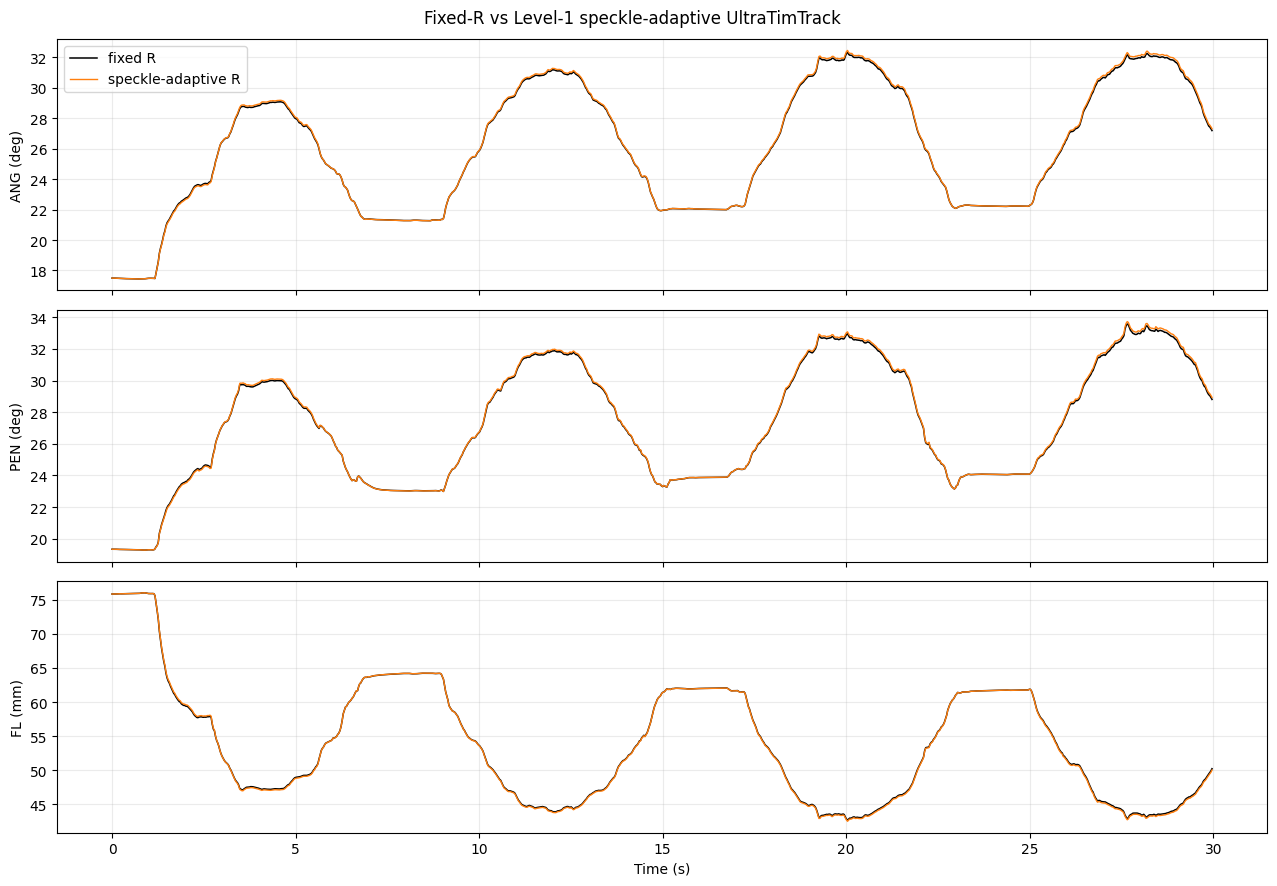

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
plot_items = [
    ('ANG (deg)', theta_fixed, theta_adaptive),
    ('PEN (deg)', pen_fixed, pen_adaptive),
    ('FL (mm)', length_fixed, length_adaptive),
]
for ax, (label, fixed, adap) in zip(axes, plot_items):
    ax.plot(time_conf, fixed, color='black', lw=1.1, label='fixed R')
    ax.plot(time_conf, adap, color='tab:orange', lw=1.0, label='speckle-adaptive R')
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel('Time (s)')
axes[0].legend(loc='best')
fig.suptitle('Fixed-R vs Level-1 speckle-adaptive UltraTimTrack')
fig.tight_layout()
path = OUT / 'fixed_vs_adaptive_ANG_PEN_FL.png'
fig.savefig(path, dpi=170)
path

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook62_forward_backward_speckle_adaptive_R/forward_backward_confidence_Rscale_ZNCC_validity.png')

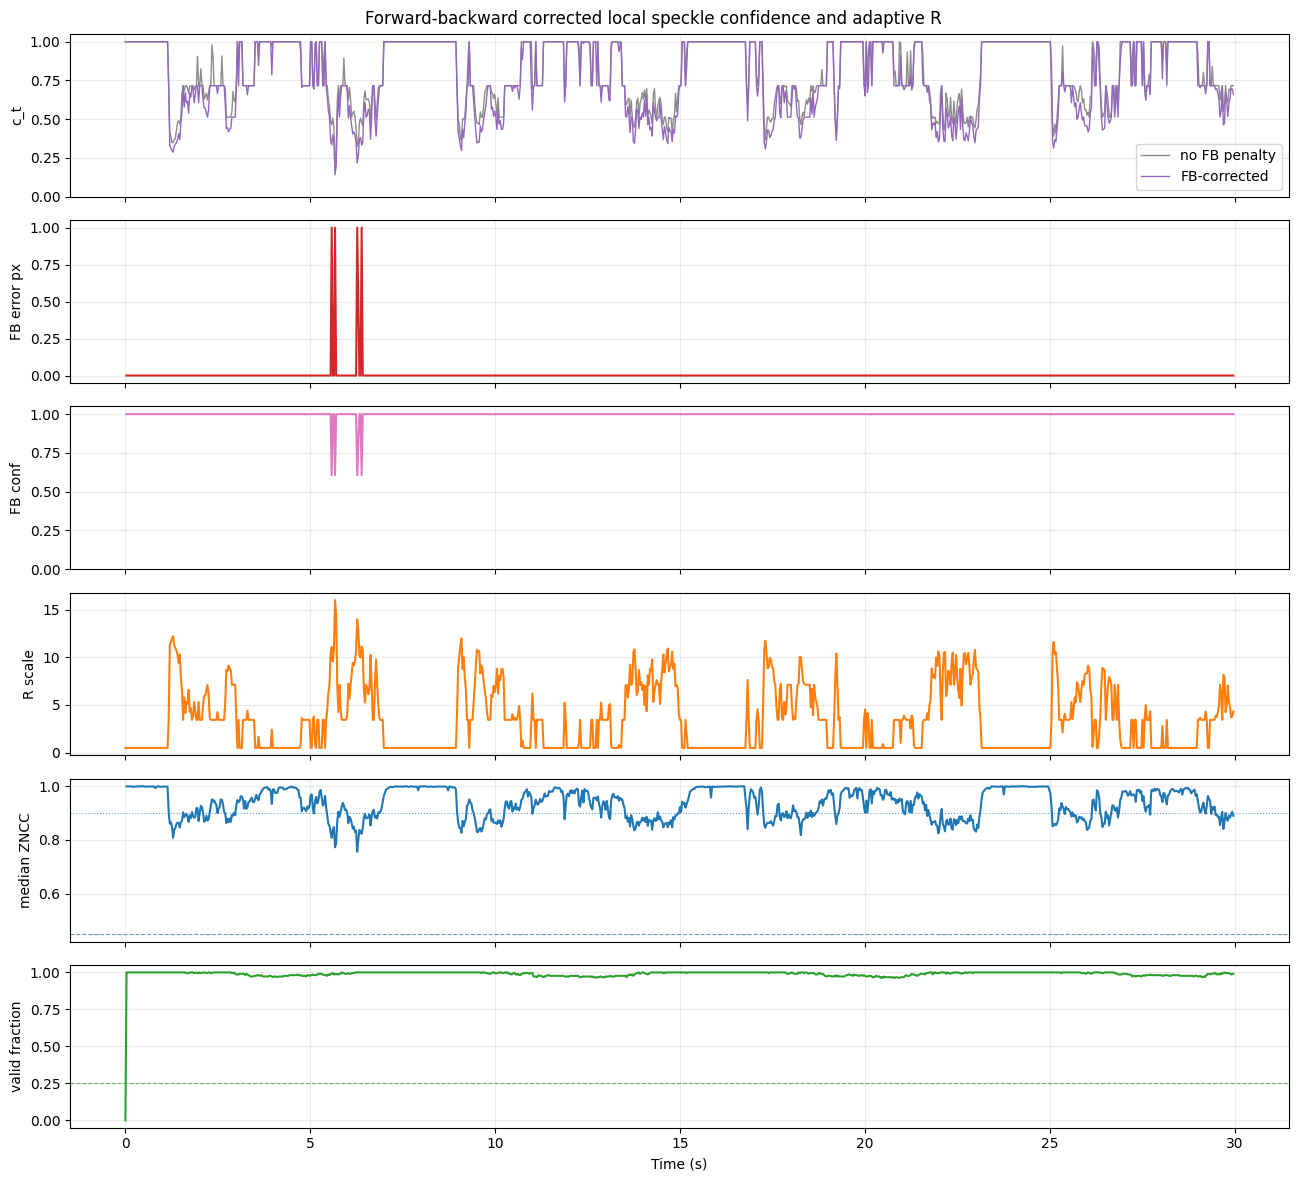

In [10]:
fig, axes = plt.subplots(6, 1, figsize=(13, 12), sharex=True)
axes[0].plot(time_conf, conf_data['combined_confidence_no_fb'], color='0.55', lw=1.0, label='no FB penalty')
axes[0].plot(time_conf, conf_data['combined_confidence'], color='tab:purple', lw=1.0, label='FB-corrected')
axes[0].set_ylabel('c_t')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')
axes[1].plot(time_conf, conf_data['median_forward_backward_error'], color='tab:red')
axes[1].set_ylabel('FB error px')
axes[2].plot(time_conf, conf_data['median_forward_backward_confidence'], color='tab:pink')
axes[2].set_ylabel('FB conf')
axes[2].set_ylim(0, 1.05)
axes[3].plot(time_conf, R_scale_conf, color='tab:orange')
axes[3].set_ylabel('R scale')
axes[4].plot(time_conf, conf_data['median_zncc'], color='tab:blue')
axes[4].axhline(CONFIG.zncc_low, color='tab:blue', ls='--', lw=0.8, alpha=0.7)
axes[4].axhline(CONFIG.zncc_high, color='tab:blue', ls=':', lw=0.8, alpha=0.7)
axes[4].set_ylabel('median ZNCC')
axes[5].plot(time_conf, conf_data['valid_fraction'], color='tab:green')
axes[5].axhline(VALID_FRACTION_FLOOR, color='tab:green', ls='--', lw=0.8, alpha=0.7)
axes[5].set_ylabel('valid fraction')
axes[5].set_xlabel('Time (s)')
for ax in axes:
    ax.grid(True, alpha=0.25)
fig.suptitle('Forward-backward corrected local speckle confidence and adaptive R')
fig.tight_layout()
path = OUT / 'forward_backward_confidence_Rscale_ZNCC_validity.png'
fig.savefig(path, dpi=170)
path


## 15. Example Frame Overlay

The overlay shows sampled blocks, local displacement vectors, and local confidence color. This is a qualitative check that the confidence comes from sensible tissue motion rather than arbitrary image regions.

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook62_forward_backward_speckle_adaptive_R/example_forward_backward_block_displacement_overlay.png')

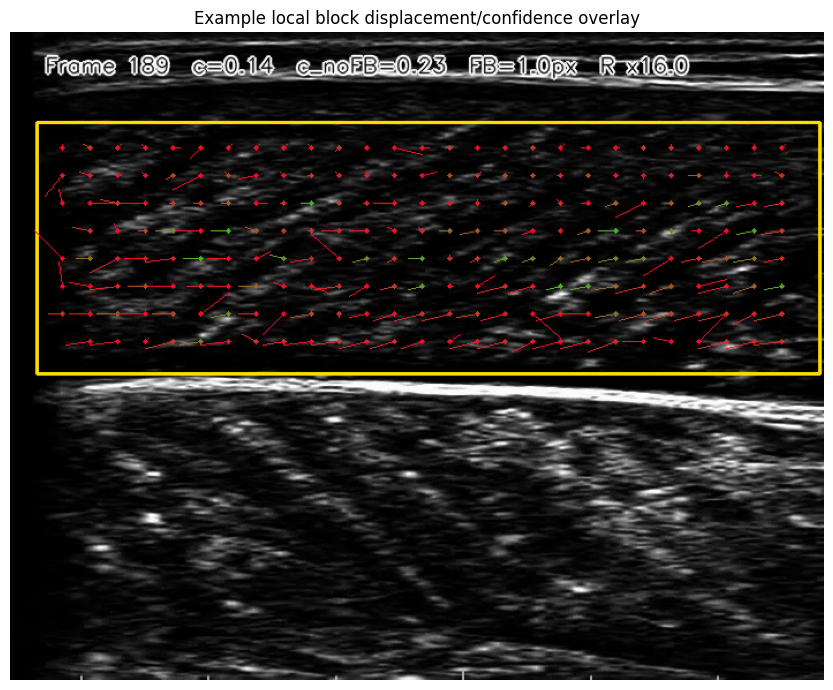

In [11]:
example_idx = int(np.nanargmax(R_scale_conf)) if np.any(np.isfinite(R_scale_conf)) else min(n_conf - 1, 1)
frames_for_overlay = read_gray_frames(VIDEO, limit=example_idx + 1)
frame = frames_for_overlay[example_idx]
vis = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
points = conf_data['sample_points']
disp = conf_data['displacements'][example_idx]
local_c = conf_data['local_confidence'][example_idx]
valid = conf_data['valid_mask'][example_idx]
x, y, w, h = fascicle_roi
cv2.rectangle(vis, (x, y), (x + w, y + h), (255, 220, 0), 2)
for point, d, c, ok in zip(points, disp, local_c, valid):
    if not ok or not np.all(np.isfinite(d)):
        continue
    p0 = tuple(np.rint(point).astype(int))
    p1 = tuple(np.rint(point + 3.0 * d).astype(int))
    color = (int(255 * (1 - c)), int(255 * c), 40)
    cv2.circle(vis, p0, 2, color, -1)
    cv2.line(vis, p0, p1, color, 1)
label = (
    f'Frame {example_idx}  c={conf_data["combined_confidence"][example_idx]:.2f}  '
    f'c_noFB={conf_data["combined_confidence_no_fb"][example_idx]:.2f}  '
    f'FB={conf_data["median_forward_backward_error"][example_idx]:.1f}px  '
    f'R x{R_scale_conf[example_idx]:.1f}'
)
cv2.putText(vis, label, (30, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (255, 255, 255), 3, cv2.LINE_AA)
cv2.putText(vis, label, (30, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (0, 0, 0), 1, cv2.LINE_AA)

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(vis)
ax.set_axis_off()
ax.set_title('Example local block displacement/confidence overlay')
fig.tight_layout()
path = OUT / 'example_forward_backward_block_displacement_overlay.png'
fig.savefig(path, dpi=170)
path


## 15J. Optional Exploratory Strain Signal

This is **not validated** and is not a FEM/mechanics-informed model. It is only a sparse affine-gradient sanity check from the local displacement field. Treat `epsilon_f` as a research diagnostic, not an output measurement.

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook62_forward_backward_speckle_adaptive_R/exploratory_fascicle_direction_strain.png')

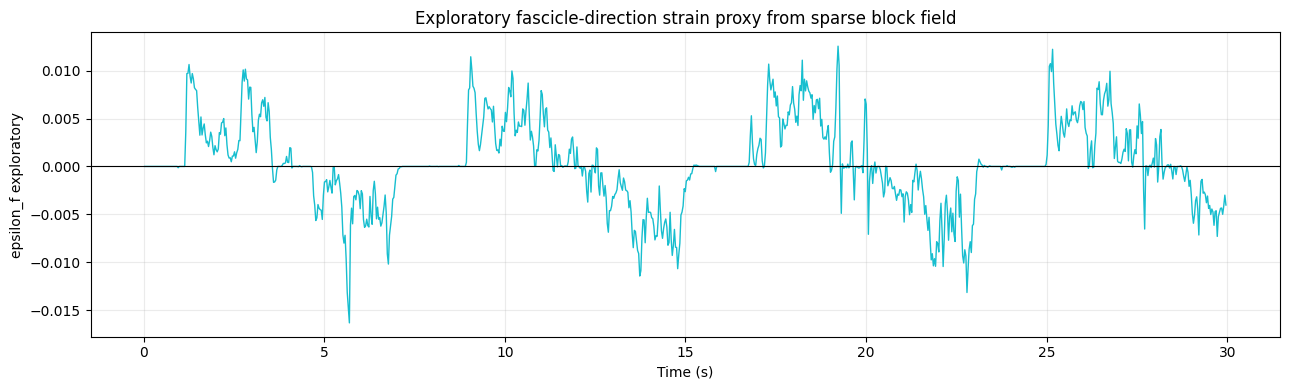

In [12]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(time_conf, conf_data['epsilon_f_exploratory'], color='tab:cyan', lw=1.0)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('epsilon_f exploratory')
ax.set_title('Exploratory fascicle-direction strain proxy from sparse block field')
ax.grid(True, alpha=0.25)
fig.tight_layout()
path = OUT / 'exploratory_fascicle_direction_strain.png'
fig.savefig(path, dpi=170)
path

## 17. Findings and Limitations

This notebook tests the starting rule-of-thumb configuration with a forward-backward consistency penalty in the local speckle confidence. The saved diagnostics include both `combined_confidence_no_fb` and `combined_confidence`, so the effect of using the forward-backward error is explicit.

Interpretation guide:

- high `median_zncc`, high valid fraction, and low forward-backward error should produce high confidence and low `R_scale`
- high ZNCC with high forward-backward error is treated as suspicious because the match is not reversible
- `confidence_floor = 0.05` prevents total collapse to zero confidence while still allowing `R_scale` to approach the high end
- `r_min_scale = 0.5` lets very reliable frames reduce measurement noise below the fixed-R baseline
- `r_gamma = 1.5` gives a smoother ramp than a quadratic rule while still lifting `R` quickly as confidence degrades

Limitations:

1. The forward-backward scale is still a rule-of-thumb hyperparameter (`forward_backward_scale_px = 2.0`). It should be calibrated against visual audits and downstream stability.
2. This is a first-30-seconds proof of concept unless `MAX_SECONDS` is set to `None`.
3. Confidence is image-derived and should not be treated as ground-truth mechanics.
4. The exploratory strain signal remains a qualitative diagnostic, not a validated output.
